## 📊 Makine Öğrenimi Proje Raporu: Spor Salonu Yoğunluk Tahmini

---
Bu proje, bir spor salonundaki saatlik kişi sayısını (number_people) tahmin etmek amacıyla geliştirilmiş bir denetimli öğrenme (supervised learning) regresyon problemidir. Çalışmada verinin içeriye alınması, **keşifsel veri analizi (EDA)**, **veri ön işleme**, **baseline (temel) modellerin kurulması** ve **Ensemble (Topluluk)** tekniklerinden **Random Forest** kullanılarak hiperparametre optimizasyonu adımları başarıyla uygulanmıştır.

---

### Adım 1: Veri Yükleme ve Keşifsel Veri Analizi (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("gym_crowdedness.csv")

In [3]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  str    
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 5.2 MB


In [5]:
# Zaman verisinin dönüştürülmesi ve yıl özelliğinin çıkarılması
df['date'] = pd.to_datetime(df["date"], utc=True)
df['year'] = df['date'].dt.year

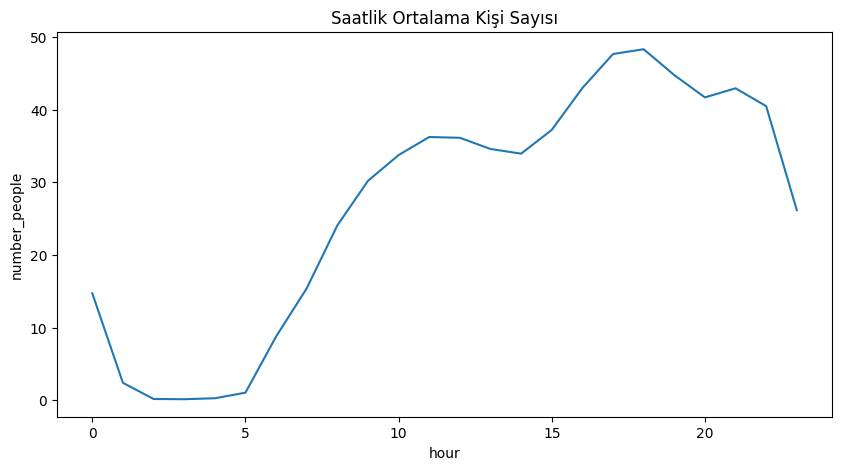

In [6]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="hour", y="number_people", errorbar=None)
plt.title("Saatlik Ortalama Kişi Sayısı")
plt.show()

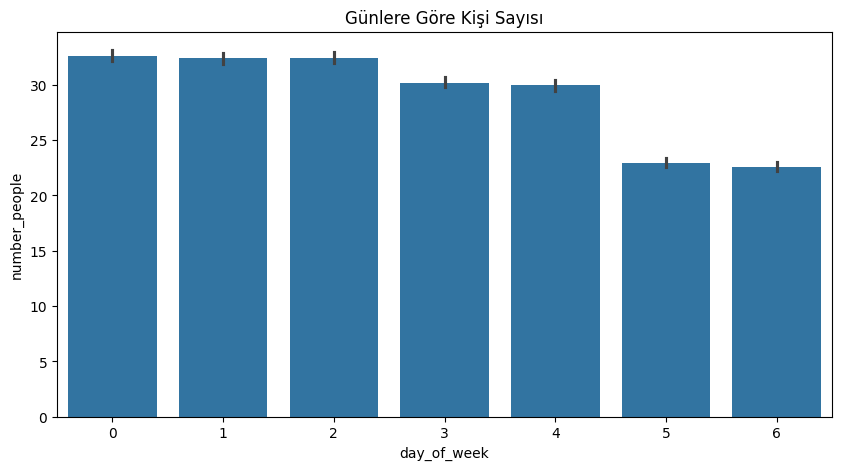

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="day_of_week", y="number_people")
plt.title("Günlere Göre Kişi Sayısı")
plt.show()

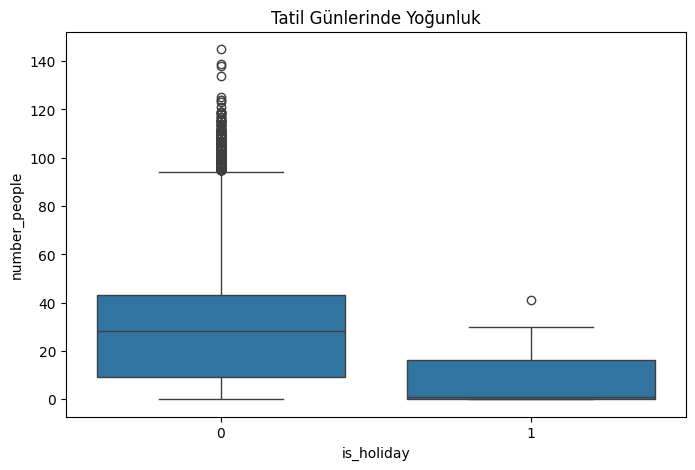

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_holiday", y="number_people")
plt.title("Tatil Günlerinde Yoğunluk")
plt.show()

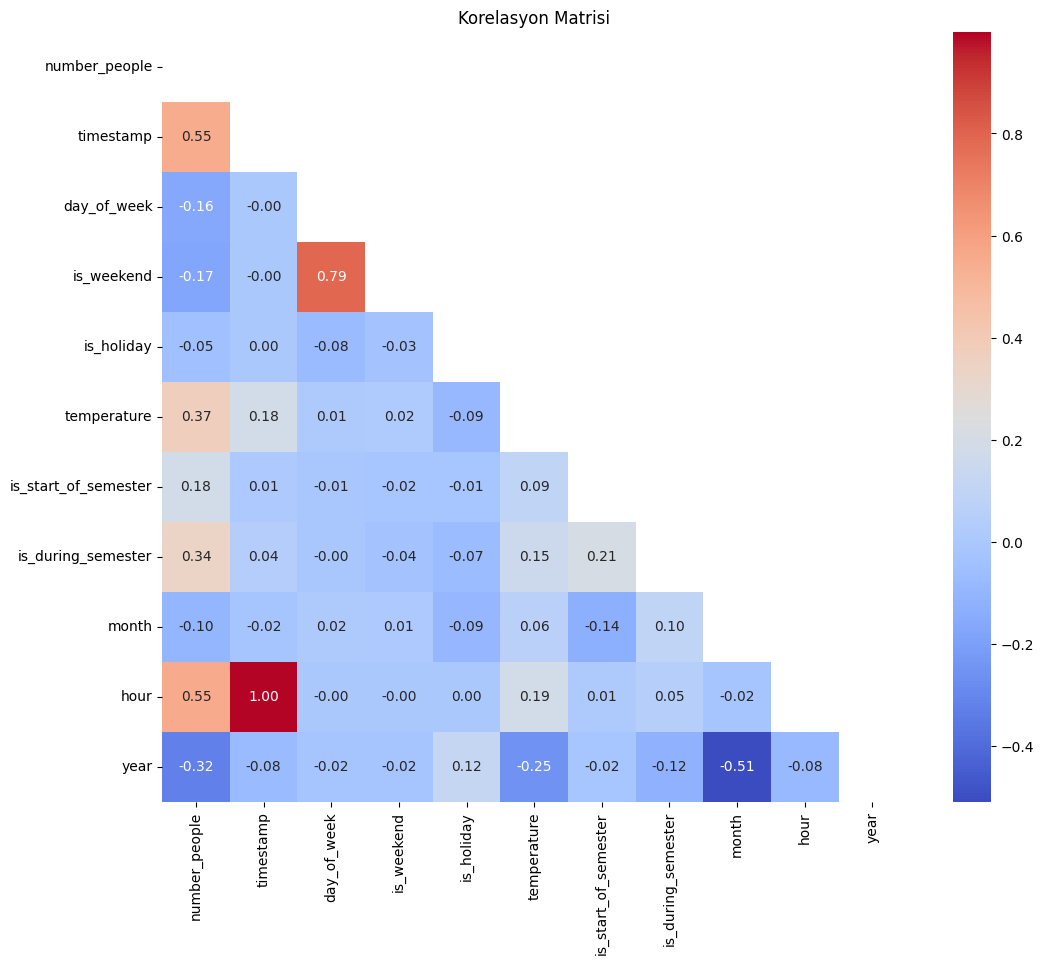

In [12]:
plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(df.corr(numeric_only=True),dtype=bool))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f",mask=mask)
plt.title("Korelasyon Matrisi")
plt.show()

In [13]:
# Modelde kullanılmayacak kolonların düşürülmesi
# Not: Hataları yoksaymak için errors='ignore' eklendi.
df.drop(["date", "timestamp"], axis=1, inplace=True, errors='ignore')

### Adım 2: Veri Ön İşleme (Pre-processing)

In [14]:
X = df.drop('number_people', axis=1)
y = df['number_people']

In [15]:
# Veri setinin %70 eğitim, %30 test olacak şekilde ayrılması
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
scaler = StandardScaler()

In [17]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Adım 3 : Model Değerlendirme Fonksiyonu

In [18]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

### Adım 4: Temel Modellerin (Baseline) Kurulması ve Eğitimi

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}

In [20]:
print("--- TEMEL MODEL PERFORMANSLARI ---")
for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2 = calculate_model_metrics(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(f"Model: {name}")
    print(f"Eğitim Seti -> RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}")
    print(f"Test Seti   -> RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")
    print("-" * 50)

--- TEMEL MODEL PERFORMANSLARI ---
Model: Linear Regression
Eğitim Seti -> RMSE: 14.3696 | MAE: 10.7477 | R2: 0.5987
Test Seti   -> RMSE: 14.3207 | MAE: 10.7092 | R2: 0.6021
--------------------------------------------------
Model: Lasso
Eğitim Seti -> RMSE: 14.6161 | MAE: 10.9495 | R2: 0.5848
Test Seti   -> RMSE: 14.5669 | MAE: 10.9263 | R2: 0.5883
--------------------------------------------------
Model: Ridge
Eğitim Seti -> RMSE: 14.3696 | MAE: 10.7477 | R2: 0.5987
Test Seti   -> RMSE: 14.3207 | MAE: 10.7092 | R2: 0.6021
--------------------------------------------------
Model: K-Neighbors Regressor
Eğitim Seti -> RMSE: 5.5959 | MAE: 3.7519 | R2: 0.9391
Test Seti   -> RMSE: 7.2948 | MAE: 4.8992 | R2: 0.8968
--------------------------------------------------
Model: Decision Tree
Eğitim Seti -> RMSE: 4.6658 | MAE: 3.1477 | R2: 0.9577
Test Seti   -> RMSE: 6.5050 | MAE: 4.3563 | R2: 0.9179
--------------------------------------------------
Model: Random Forest Regressor
Eğitim Seti -> R

### Adım 5 : Hiperparametre Optimizasyonu (RandomizedSearchCV)

In [21]:
knn_params = {"n_neighbors": [2, 3, 10, 20, 40, 50]}

In [22]:
rf_params = {
    "max_depth": [5, 8, 10, 15, None],
    "max_features": ["sqrt", "log2", 5, 7, 10],
    "min_samples_split": [2, 8, 12, 20],
    "n_estimators": [100, 200, 500, 1000]
}

In [23]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("Random Forest", RandomForestRegressor(random_state=42), rf_params)
]

In [24]:
print("\n--- HİPERPARAMETRE OPTİMİZASYONU ---")
for name, model, params in randomcv_models:
    # Not: Büyük verilerde n_iter=100 uzun sürebilir, test aşamasında düşürülebilir.
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=100, cv=3, n_jobs=-1, random_state=42)
    randomcv.fit(X_train, y_train)
    print(f"En iyi parametreler ({name}): {randomcv.best_params_}")


--- HİPERPARAMETRE OPTİMİZASYONU ---


C:\Users\POLAT\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


En iyi parametreler (KNN): {'n_neighbors': 2}
En iyi parametreler (Random Forest): {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


### Adım 6 : Optimize Edilmiş Nihai Modellerin Testi
>RandomizedSearchCV'den elde edilen en iyi parametrelerle modellerin kurulması

In [25]:
final_models = {
    "Tuned K-Neighbors Regressor": KNeighborsRegressor(n_neighbors=2),
    "Tuned Random Forest Regressor": RandomForestRegressor(
        n_estimators=500,
        min_samples_split=2,
        max_features=7,
        max_depth=None,
        random_state=42
    )
}

In [26]:
print("\n--- NİHAİ (TUNE EDİLMİŞ) MODEL PERFORMANSLARI ---")
for name, model in final_models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2 = calculate_model_metrics(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(f"Model: {name}")
    print(f"Eğitim Seti -> RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}")
    print(f"Test Seti   -> RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")
    print("-" * 50)


--- NİHAİ (TUNE EDİLMİŞ) MODEL PERFORMANSLARI ---
Model: Tuned K-Neighbors Regressor
Eğitim Seti -> RMSE: 5.4037 | MAE: 3.5401 | R2: 0.9432
Test Seti   -> RMSE: 6.8982 | MAE: 4.6223 | R2: 0.9077
--------------------------------------------------
Model: Tuned Random Forest Regressor
Eğitim Seti -> RMSE: 4.6984 | MAE: 3.1915 | R2: 0.9571
Test Seti   -> RMSE: 6.3344 | MAE: 4.2861 | R2: 0.9222
--------------------------------------------------
